# Spurious Retransmissions

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
import statistics
from common import *
from typing import List, Optional
from experiment import NetworkSetting
from data.http import HTTPExperiment, PlottableDataPoint
from data.media import MediaExperiment
from treatments.picoquic import treatment_map as http_treatment_map, NETWORK_SETTING as http_network_setting
from treatments.media import treatment_map as media_treatment_map, NETWORK_SETTING as media_network_setting

## Parse data

In [2]:
# HTTP benchmark
data_size = 125000 * 20 * 10 # 125000 * bottleneck_bw * time_s

def plot_loss_vs_num_spurious(prefix, raw_data, sender: bool):
    key = 'Sender' if sender else 'Receiver'
    def num_spurious_func(output):
        if 'additional_data' not in output:
            return 0
        data_key = f'num_spurious_{key.lower()}'
        if data_key not in output['additional_data']:
            print(output['additional_data'])
        return output['additional_data'][data_key]
    
    title = f'{prefix} {data_size_str(DATA_SIZES()[0])} ({NETWORK_SETTINGS()[0].label()})'
    plottable_data = raw_data.to_plottable_data(num_spurious_func)
    plot_loss_vs_metric_line(plottable_data, title=title, ylabel=f'Num Spurious Retransmissions ({key})')

def parse_http_data(labels, num_trials=1, network_setting=http_network_setting, data_size=data_size, execute=False, sender=False, normalized=True):
    treatments = [http_treatment_map(label) for label in labels]
    exp = HTTPExperiment(num_trials=num_trials, treatments=treatments, network_settings=[network_setting], data_sizes=[data_size])
    raw_data = exp.to_raw_data(execute=execute)
    data = {}
    for label in labels:
        outputs = raw_data.data[label][network_setting.label()][data_size]
        if normalized:
            outputs = map(lambda output: output['additional_data']['num_spurious_receiver'] / output['time_s'], outputs)
        else:
            outputs = map(lambda output: output['additional_data']['num_spurious_receiver'], outputs)
        data[label] = PlottableDataPoint(list(outputs))
    return data

In [3]:
# Media benchmark
duration = 30

def parse_media_data(labels, duration=duration, network_setting=media_network_setting, execute=False, normalized=True):
    treatments = [media_treatment_map(label) for label in labels]
    exp = MediaExperiment(duration, treatments, network_setting)
    media_raw_data = exp.to_raw_data(execute=execute)
    data = {}
    for label in labels:
        output = media_raw_data.data[label]
        assert output.get('success')
        if normalized:
            output = output['client_num_spurious'] / output['time_s']
        else:
            output = output['client_num_spurious']
        data[label] = PlottableDataPoint([output])
    return data

## Plotting Functions

In [64]:
def plot_spurious_retransmissions(data, keys: List[str], title: str, style=False, ylabel: str='Num Spurious Retransmissions / Sec', ylim=0, legend=False, pdf: Optional[str]=None):
    # Example data
    width = 1.0 / (len(keys) + 1)  # the width of the bars

    # Create plot
    fig, ax = plt.subplots(figsize=(3.5,2))
    labels = []
    ymax = max([data[key].p(50) for key in keys])
    for i, key in enumerate(keys):
        y_raw = data[key]
        y = y_raw.p(50)
        bar_x = width * (i - len(keys) / 2 + 0.5)
        yerr_lower = y - y_raw.p(25)
        yerr_upper = y_raw.p(75) - y
        if style:
            label = LABEL_MAP[key]
            sty = STYLE[label]
            title = None
            bar = ax.bar(bar_x, y, width, capsize=5, yerr=[[yerr_lower],[yerr_upper]], label=label, color=sty.color)
        else:
            label = key
            bar = ax.bar(bar_x, y, width, capsize=5, yerr=[[yerr_lower],[yerr_upper]], label=label)
        labels.append(label)
        if y / ymax > 0.1:
            bar_offset = 0.03 * ymax
        else:
            bar_offset = y + 0.03 * ymax
        ax.text(bar_x, bar_offset, f'{y:.1f}', ha='center', fontsize=10)
    
    # Add labels, title
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(ylim)

    # Add legend
    ncol = 2
    legend_height = 1.4
    legend_height += 0.06 * (math.ceil(len(labels) / ncol) - 1)
    if legend:
        ax.legend(loc='lower left', bbox_to_anchor=(1, 0), ncol=ncol)
    ax.set_xticks([])
    plt.grid(axis='y')
    
    # Show plot
    if pdf:
        save_pdf(pdf)
    plt.show()

In [65]:
def plot_spurious_retransmissions_http(
    labels: List[str], title: str, normalized: bool=True, network_setting=http_network_setting, legend=False,
    num_trials=10, execute=False, sender: bool=False, ylim=0, pdf: Optional[str]=None, style=False,
):
    data = parse_http_data(labels, normalized=normalized, network_setting=network_setting, sender=sender, num_trials=num_trials, execute=execute)
    if normalized:
        ylabel = 'Spurious Packets / s'
    else:
        ylabel = 'Spurious Packets'
    plot_spurious_retransmissions(data, labels, title, style=style, ylabel=ylabel, legend=legend, ylim=ylim, pdf=pdf)

In [66]:
def plot_spurious_retransmissions_media(
    labels: List[str], title: str, normalized: bool=True, network_setting=media_network_setting,
    duration=30, execute=False, ylim=0, pdf: Optional[str]=None, style=False, legend=False,
):
    data = parse_media_data(labels, duration=duration, network_setting=network_setting, normalized=normalized, execute=execute)
    if normalized:
        ylabel = 'Spurious Packets / s'
    else:
        ylabel = 'Spurious Packets'
    plot_spurious_retransmissions(data, labels, title, style=style, ylabel=ylabel, legend=legend, ylim=ylim, pdf=pdf)

## HTTP Benchmark

../figures/spurious_retx_legend.pdf


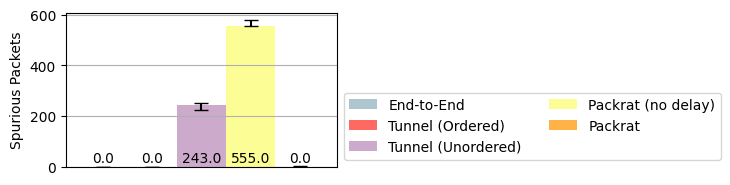

../figures/spurious_retx_http.pdf


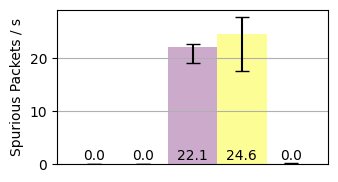

In [67]:
## 4. Sending with delay reduces spurious retx (keeps or improves perf.)
# wifi_unordered has spurious retransmissions and wifi_ordered gets rid of them
# delays = [0,5,10,20,30,60]
ylim = 0
execute = True
num_trials = 20

labels = [
    'picoquic',
    # 'picoquic_split',
    'picoquic_rtunnel_retx7_ordered32',
    'picoquic_rtunnel_retx7',
    'picoquic_iblt_0ms_hint',
    # 'picoquic_iblt_15ms_hint',
    'picoquic_iblt_30ms_hint',
]

# plot_spurious_retransmissions_http(gen_labels('sidekick', True), 'HTTP Benchmark psum (hint)', num_trials=num_trials, execute=execute, normalized=normalized, ylim=ylim)
plot_spurious_retransmissions_http(labels, 'HTTP Benchmark iblt (hint)', style=True,
                                   num_trials=num_trials, execute=execute, normalized=False, ylim=ylim,
                                   pdf='../figures/spurious_retx_legend.pdf', legend=True)
plot_spurious_retransmissions_http(labels, 'HTTP Benchmark iblt (hint)', style=True,
                                   num_trials=num_trials, execute=execute, normalized=True, ylim=ylim,
                                   pdf='../figures/spurious_retx_http.pdf')

## Media Benchmark

../figures/spurious_retx_media.pdf


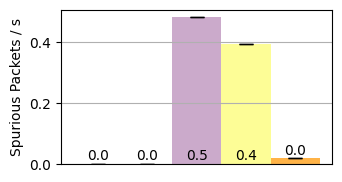

In [68]:
# 4. Sending with delay reduces spurious retx (keeps or improves perf).
delays = [0,15,30,45,90]
ylim = 0
duration = 180
normalized = True
execute = True

labels = [
    'baseline',
    'baseline_rtunnel_retx7_ordered32',
    'baseline_rtunnel_retx7',
    'iblt_delay0_hint_nack_cache4000',
    # 'iblt_delay55_hint_nack',
    'iblt_delay110_hint_nack_cache4000',
]

# plot_spurious_retransmissions_media(gen_labels('psum', False, False), 'Media Benchmark psum', ylim=ylim)
# plot_spurious_retransmissions_media(gen_labels('psum', False, True), 'Media Benchmark psum (nack)', ylim=ylim)
# plot_spurious_retransmissions_media(gen_labels('psum', True, False), 'Media Benchmark psum (hint)', ylim=ylim)
# plot_spurious_retransmissions_media(gen_labels('psum', True, True), 'Media Benchmark psum (hint+nack)', ylim=ylim, execute=execute, normalized=normalized)
# plot_spurious_retransmissions_media(gen_labels('iblt', False, False), 'Media Benchmark iblt', ylim=ylim)
# plot_spurious_retransmissions_media(gen_labels('iblt', False, True), 'Media Benchmark iblt (nack)', ylim=ylim)
# plot_spurious_retransmissions_media(gen_labels('iblt', True, False), 'Media Benchmark iblt (hint)', ylim=ylim)
plot_spurious_retransmissions_media(labels, 'Media Benchmark iblt (hint+nack)', style=True,
                                    ylim=ylim, execute=execute, normalized=normalized, duration=duration,
                                    pdf='../figures/spurious_retx_media.pdf')